## Imports

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

## Load Metadata (tracks.csv, genres.csv, echonest.csv)

Load the primary metadata tables from the FMA dataset

The tracks.csv file uses a multi-index header, which is flattened for easier use

Optional EchoNest features are also loaded if present

In [ ]:
META_PATH = "/work/NLP-mini-project/datasets/fma/fma_raw/fma_metadata"

# Load tracks with multi-index columns
tracks = pd.read_csv(f"{META_PATH}/tracks.csv", index_col=0, header=[0, 1])
genres = pd.read_csv(f"{META_PATH}/genres.csv", index_col=0)

print("Tracks shape:", tracks.shape)
print("Tracks top-level columns:", tracks.columns.levels[0][:10])

Tracks shape: (106574, 52)
Tracks top-level columns: Index(['album', 'artist', 'set', 'track'], dtype='object')


In [ ]:
# Flatten multi-index columns
tracks.columns = ["_".join(col).strip() for col in tracks.columns.values]

print("Flattened columns:", len(tracks.columns))
tracks.head()

# Load EchoNest features if available
echonest_path = f"{META_PATH}/echonest.csv"

try:
    echonest = pd.read_csv(echonest_path, index_col=0, header=[0, 1, 2])
    echonest.columns = ["_".join(col).strip() for col in echonest.columns.values]
    print("Loaded EchoNest:", echonest.shape)
    has_echonest = True
except:
    print("EchoNest missing — skipping.")
    has_echonest = False

Flattened columns: 52
Loaded EchoNest: (13129, 249)


## Merge Metadata and Select Relevant Columns

Merge track metadata with genre information and EchoNest features

Select the subset of columns that are useful for analysis and modeling


In [ ]:
df = tracks.copy()

if "track_genre_top_id" in df.columns:
    df = df.merge(
        genres[["title", "top_level", "parent"]],
        left_on="track_genre_top_id",
        right_index=True,
        how="left",
        suffixes=("", "_genreinfo"),
    )

if has_echonest:
    df = df.merge(echonest, left_index=True, right_index=True, how="left")

print("Merged metadata shape:", df.shape)
df.head()

cols_to_keep = [
    "track_title", "track_duration", "track_bit_rate", "track_genre_top",
    "track_genres", "track_genres_all", "set_split", "set_subset",
    "album_id", "artist_id",
    "echonest_audio_features_acousticness", "echonest_audio_features_danceability",
    "echonest_audio_features_energy", "echonest_audio_features_instrumentalness",
    "echonest_audio_features_liveness", "echonest_audio_features_speechiness",
    "echonest_audio_features_tempo", "echonest_audio_features_valence",
]

df = df[[c for c in cols_to_keep if c in df.columns]]
print("Shape after column selection:", df.shape)
df.head()

## Missing Value Analysis

Check missing values across all selected metadata fields

This includes detecting empty lists for genre annotations

In [ ]:
# Helper for detecting "[]" empty lists
def is_empty_list(x):
    if isinstance(x, str):
        try:
            val = eval(x)
        except:
            return False
        return isinstance(val, list) and len(val) == 0
    return False

# Compute null-values per column
missing_summary = []

for col in df.columns:
    empty = (
        df[col].apply(is_empty_list)
        if col in ["track_genres", "track_genres_all"]
        else False
    )
    missing_percent = ((df[col].isna() | empty).mean()) * 100
    missing_summary.append((col, round(missing_percent, 2)))

missing_df = pd.DataFrame(missing_summary, columns=["column", "% missing"])
missing_df.sort_values(by="% missing", ascending=False)

,column,% missing
16,echonest_audio_features_tempo,87.68
17,echonest_audio_features_valence,87.68
13,echonest_audio_features_instrumentalness,87.68
12,echonest_audio_features_energy,87.68
15,echonest_audio_features_speechiness,87.68
14,echonest_audio_features_liveness,87.68
11,echonest_audio_features_danceability,87.68
10,echonest_audio_features_acousticness,87.68
3,track_genre_top,53.46
4,track_genres,2.09


## Genre Hierarchy (Tree Structure)

Build and print the hierarchical tree of FMA genres based on the parent–child relationships in genres.csv

In [ ]:
children = {}
for gid, row in genres.iterrows():
    parent = int(row["parent"])
    children.setdefault(parent, []).append(gid)

def print_tree(node, level=0):
    indent = "   " * level
    title = genres.loc[node, "title"]
    print(f"{indent}- {title} ({node})")
    if node in children:
        for child in children[node]:
            if child != node:
                print_tree(child, level + 1)

print("Genre Hierarchy:\n")
for top in genres[genres["parent"] == 0].index:
    print_tree(top)

## Extract Top-Level Genres and Plot Counts

Extract only top-level genres for each track and count how many top-level labels each track has

Visualize the distribution of the number of genres per track

In [ ]:
# Set of all top-level genres (IDs)
top_ids = {2, 3, 4, 5, 8, 9, 10, 12, 13, 14, 15, 17, 20, 21, 38, 1235}

# Extract top-level genres per track
def extract_top_levels(x):
    if isinstance(x, str):
        ids = eval(x)  # convert "[21, 103]" → [21, 103]
    else:
        ids = x
    return [g for g in ids if g in top_ids]


df["top_genres"] = df["track_genres_all"].apply(extract_top_levels)
df["num_top"] = df["top_genres"].apply(len)

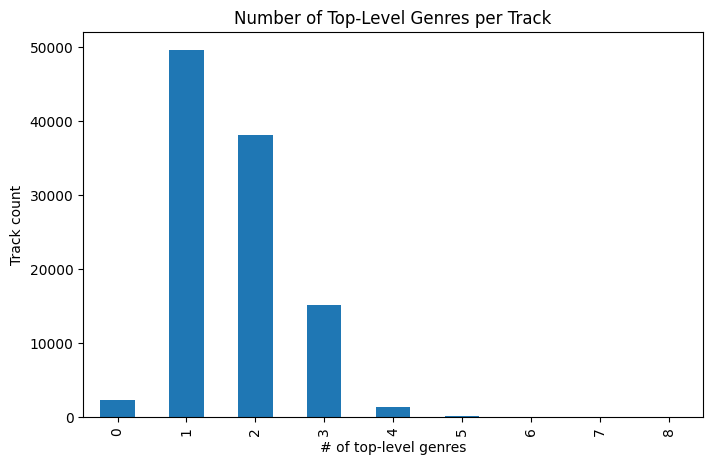

In [ ]:
# Plot number of top-level genres
df["num_top"].value_counts().sort_index().plot(kind="bar", figsize=(8, 5))
plt.title("Number of Top-Level Genres per Track")
plt.xlabel("# of top-level genres")
plt.ylabel("Track count")
plt.show()

## Single-Label Genre Distribution

Focus on tracks labeled with exactly one top-level genre

Plot the distribution of single-genre labels

In [ ]:
df_single = df[df["num_top"] == 1].copy()
df_single["single_top"] = df_single["top_genres"].apply(lambda x: x[0])

label_counts = df_single["single_top"].value_counts()
label_counts_named = label_counts.rename(index=id_to_title)

label_counts_named.plot(kind="bar", figsize=(12, 6))
plt.xticks(rotation=60)
plt.title("Distribution of Single-Label Top Genres")
plt.ylabel("Track count")
plt.show()

## Multi-Label Frequencies, Cardinality, Density and absolute Genre Co-Occurrence Matrix

Convert genre assignments into binary multi-label format

Compute per-genre frequencies, label cardinality, label density, and the absolute co-occurrence matrix of genres

Visualize co-occurrence using a heatmap


In [ ]:
# Sort for consistent ordering
label_list = sorted(top_ids)
id_to_title = genres["title"].to_dict()

df_ml = df.copy()
for g in label_list:
    df_ml[f"label_{g}"] = df_ml["top_genres"].apply(lambda lst: int(g in lst))

label_freq = {g: df_ml[f"label_{g}"].sum() for g in label_list}
label_freq_named = pd.Series(
    {id_to_title[g]: label_freq[g] for g in label_list}
).sort_values(ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(label_freq_named.index, label_freq_named.values)
plt.xticks(rotation=60, ha="right")
plt.title("Multi-Label Genre Frequencies")
plt.ylabel("Track count")
plt.tight_layout()
plt.show()

df_ml["num_labels"] = df_ml["top_genres"].apply(len)
label_cardinality = df_ml["num_labels"].mean()
num_labels = len(label_list)
label_density = label_cardinality / num_labels
print("Label cardinality (avg labels per track):", round(label_cardinality, 3))
print("Label density:", round(label_density, 5))

co_matrix = np.zeros((num_labels, num_labels))
for lst in df_ml["top_genres"]:
    for g1 in lst:
        for g2 in lst:
            i = label_list.index(g1)
            j = label_list.index(g2)
            co_matrix[i, j] += 1

plt.figure(figsize=(10, 8))
plt.imshow(co_matrix, cmap="Blues")
plt.xticks(range(num_labels), [id_to_title[g] for g in label_list], rotation=90)
plt.yticks(range(num_labels), [id_to_title[g] for g in label_list])
plt.colorbar()
plt.title("Top-Level Genre Co-Occurrence Matrix")
plt.tight_layout()
plt.show()

## Relative Co-Occurrence (Row-Normalized)

Normalize the co-occurrence matrix row-wise to understand the relative likelihood of one genre co-occurring with another

Visualize normalized probabilities as a heatmap

In [ ]:
row_sums = co_matrix.sum(axis=1, keepdims=True)
co_matrix_rel = np.nan_to_num(co_matrix / row_sums)

plt.figure(figsize=(10, 8))
plt.imshow(co_matrix_rel, cmap="Blues", vmin=0, vmax=1)
plt.xticks(range(num_labels), [id_to_title[g] for g in label_list], rotation=90)
plt.yticks(range(num_labels), [id_to_title[g] for g in label_list])
plt.colorbar(label="Co-occurrence probability (row-normalized)")
plt.title("Relative Top-Level Genre Co-Occurrence (Row-Normalized)")
plt.tight_layout()
plt.show()

In [18]:
ratio = label_freq_named.max() / label_freq_named.min()
print("Imbalance ratio:", ratio)

Imbalance ratio: 52.26575342465753
